Data Preparation and Sampling
This stage examines the cleaned population, checks potential outliers using the IQR rule, visualises the data, and draws a reproducible stratified sample of 64 Forwards and 64 Midfielders.

NB: potential outliers are flagged, not automatically deleted. Extreme SoT/90 values can be legitimate football performances, so removing them without a substantive reason could bias the analysis.


In [65]:
#Import necessary libraries
import pandas as pd #pandas is used for data manipulation and analysis, providing data structures and operations for manipulating numerical tables.
import numpy as np  #numpy is used for numerical computing in Python, providing support for large, multi-dimensional arrays, along with a collection of mathematical functions to operate on these arrays.
import matplotlib.pyplot as plt #Matplotlib is a plotting library, it provides an object-oriented API for embedding plots into applications.
import os #os module provides a way of using operating system dependent functionality like reading or writing to the file system.

# Check if the cleaned population CSV exists before proceeding.Raise an error with solution instructions if it doesnt exist.
input_file = "Wrangled_player_data.csv"
if not os.path.exists(input_file):
    raise FileNotFoundError("Run Notebook 1 first to create the cleaned population CSV.")

df_clean = pd.read_csv(input_file)#Read the wrangled player data into a pandas 

#print
print("Cleaned population shape:", df_clean.shape)
print(df_clean["Position_Group"].value_counts())
display(df_clean.head())


Cleaned population shape: (608, 11)
Position_Group
Midfielder    385
Forward       223
Name: count, dtype: int64


,Player,Pos,Squad,Age,90s,Sh,SoT,SoT/90,Primary_Position,Position_Group,Player_ID
0,Brenden Aaronson,MF,us USA,25,0.8,3,1,1.18,MF,Midfielder,PL0001
1,Thelo Aasgaard,MF,no Norway,24,1.0,2,1,1.00,MF,Midfielder,PL0002
2,Hamza Abdelkarim,FW,eg Egypt,18,0.7,0,0,0.00,FW,Forward,PL0003
3,Yusuf Abdurisag,FW,qa Qatar,26,1.1,0,0,0.00,FW,Forward,PL0004
4,Elias Achouri,"FW,MF",tn Tunisia,27,0.5,3,1,2.09,FW,Forward,PL0005


In [66]:
# Check potential SoT/90 outliers separately within each position group using the IQR rule.

# Calculate Q1 for SoT/90 separately within each position group.
q1 = df_clean.groupby("Position_Group")["SoT/90"].transform( 
    lambda x: x.quantile(0.25)  # Calculate the first quartile for each position group
)

# Calculate Q3 for SoT/90 separately within each position group.
q3 = df_clean.groupby("Position_Group")["SoT/90"].transform(
    lambda x: x.quantile(0.75)  # Calculate the third quartile for each position group
)

# Calculate the interquartile range (IQR).
iqr = q3 - q1

# Calculate the lower and upper IQR bounds for each player
# based on the position group they belong to.
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Create a copy of the cleaned DataFrame so the original data is not changed.
df_prepared = df_clean.copy()

# Add the calculated lower and upper IQR bounds to the DataFrame.
df_prepared["IQR_Lower_Bound"] = lower
df_prepared["IQR_Upper_Bound"] = upper

# Flag players whose SoT/90 value falls below the lower bound
# or above the upper bound as potential outliers.
df_prepared["Potential_Outlier"] = (
    (df_prepared["SoT/90"] < df_prepared["IQR_Lower_Bound"]) |
    (df_prepared["SoT/90"] > df_prepared["IQR_Upper_Bound"])
)

# Reset the index to keep a clean sequential index.
df_prepared = df_prepared.reset_index(drop=True)

# Prepare a summary of potential outliers by position group.
outlier_summary = (
    df_prepared.groupby("Position_Group")["Potential_Outlier"]
    .agg(["sum", "count"])
    .rename(
        columns={
            "sum": "Potential_Outliers",
            "count": "Total_Players"
        }
    )
)

# Calculate the percentage of potential outliers in each position group.
outlier_summary["Percent_Outliers"] = (
    100
    * outlier_summary["Potential_Outliers"]
    / outlier_summary["Total_Players"]
)

# Display the summary of potential outliers.
print("Potential SoT/90 outliers using the 1.5 × IQR rule:")
display(outlier_summary)

# Display the individual players flagged as potential outliers.
print("\nPotential outlier records:")

display(
    df_prepared.loc[
        df_prepared["Potential_Outlier"],
        [
            "Player_ID",
            "Player",
            "Position_Group",
            "90s",
            "SoT/90",
            "IQR_Lower_Bound",
            "IQR_Upper_Bound"
        ]
    ]
    .sort_values(
        ["Position_Group", "SoT/90"],
        ascending=[True, False]
    )
)

Potential SoT/90 outliers using the 1.5 × IQR rule:


,Potential_Outliers,Total_Players,Percent_Outliers
Position_Group,,,
Forward,10,223,4.484305
Midfielder,25,385,6.493506



Potential outlier records:


,Player_ID,Player,Position_Group,90s,SoT/90,IQR_Lower_Bound,IQR_Upper_Bound
151,PL0152,Ismael Díaz,Forward,0.4,4.86,-1.8825,3.1375
18,PL0019,Almoez Ali,Forward,0.2,4.74,-1.8825,3.1375
387,PL0388,Neymar,Forward,0.4,4.62,-1.8825,3.1375
247,PL0248,Yang Hyun-jun,Forward,0.2,4.50,-1.8825,3.1375
75,PL0076,Nadhir Benbouali,Forward,0.5,4.00,-1.8825,3.1375
341,PL0342,Jean-Philippe Mateta,Forward,0.3,3.75,-1.8825,3.1375
381,PL0382,Duckens Nazon,Forward,0.3,3.75,-1.8825,3.1375
591,PL0592,Tete Yengi,Forward,0.3,3.75,-1.8825,3.1375
105,PL0106,Jaminton Campaz,Forward,0.8,3.60,-1.8825,3.1375
135,PL0136,Promise David,Forward,0.9,3.38,-1.8825,3.1375


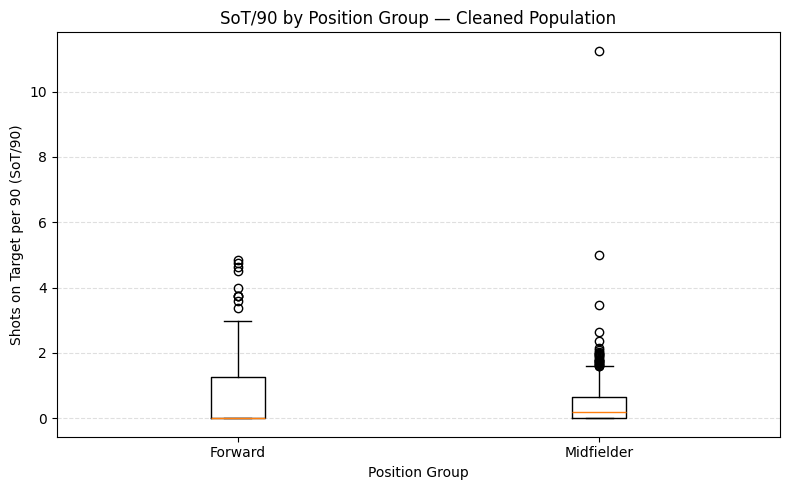

In [67]:
# Boxplot: useful for seeing median, spread and potential extreme values.
plt.figure(figsize=(8, 5)) # Set the figure size
data_to_plot = [  #Specify the data to be plotted in the boxplot.
    df_prepared.loc[df_prepared["Position_Group"] == "Forward", "SoT/90"],
    df_prepared.loc[df_prepared["Position_Group"] == "Midfielder", "SoT/90"]
]
#Create the boxplot and customize its appearance with titles, labels, grid lines, and layout adjustments.
plt.boxplot(data_to_plot, tick_labels=["Forward", "Midfielder"])
plt.title("SoT/90 by Position Group — Cleaned Population")
plt.xlabel("Position Group")
plt.ylabel("Shots on Target per 90 (SoT/90)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

#The boxplot's 

In [68]:
#Boxplot Interpretation:
'''
This visualization allows for a quick comparison of shots on target per 90 minutes between the two position groups, highlighting differences in central tendency, variability, and the presence of extreme values'''
 
'''Both groups display positively skewed distributions, with most observations concentrated at relatively low SoT/90 values and several high-value outliers. 
Forwards show greater variability in the central portion of the distribution, while Midfielders have a narrower interquartile range but contain several extreme observations, including one value above 11 SoT/90.
The presence of these outliers suggests that the mean may be influenced by extreme values.
Since the analytical question concerns differences in mean SoT/90, descriptive statistics and subsequent inferential analysis are required to determine whether Forwards have a significantly higher average than Midfielders.'''

'Both groups display positively skewed distributions, with most observations concentrated at relatively low SoT/90 values and several high-value outliers. \nForwards show greater variability in the central portion of the distribution, while Midfielders have a narrower interquartile range but contain several extreme observations, including one value above 11 SoT/90.\nThe presence of these outliers suggests that the mean may be influenced by extreme values.\nSince the analytical question concerns differences in mean SoT/90, descriptive statistics and subsequent inferential analysis are required to determine whether Forwards have a significantly higher average than Midfielders.'

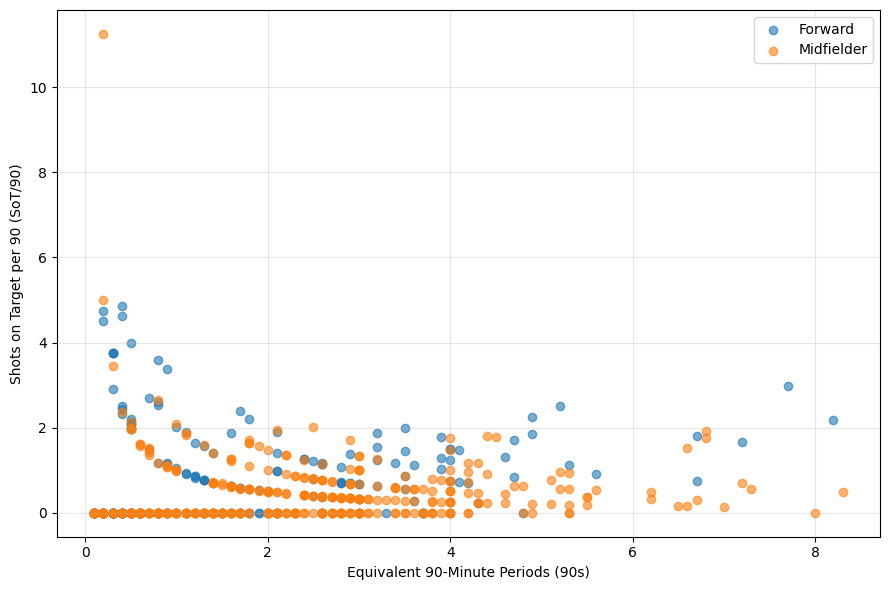

In [69]:
# Scatterplot: examine whether SoT/90 behaves differently for players with different playing time.
plt.figure(figsize=(9, 6)) #Set the figure size

# Loop through each position group and create a scatter plot of 90s vs SoT/90 for players in that group, with different colors and labels for each position.
for position in ["Forward", "Midfielder"]:
    subset = df_prepared[df_prepared["Position_Group"] == position]
    plt.scatter(subset["90s"], subset["SoT/90"], alpha=0.6, label=position) # Define the scatter plot for each position group.("Playing Time vs Shots on Target per 90")
    
# Add titles, labels, legend, grid, and layout adjustments to the scatter plot.    
plt.xlabel("Equivalent 90-Minute Periods (90s)")
plt.ylabel("Shots on Target per 90 (SoT/90)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


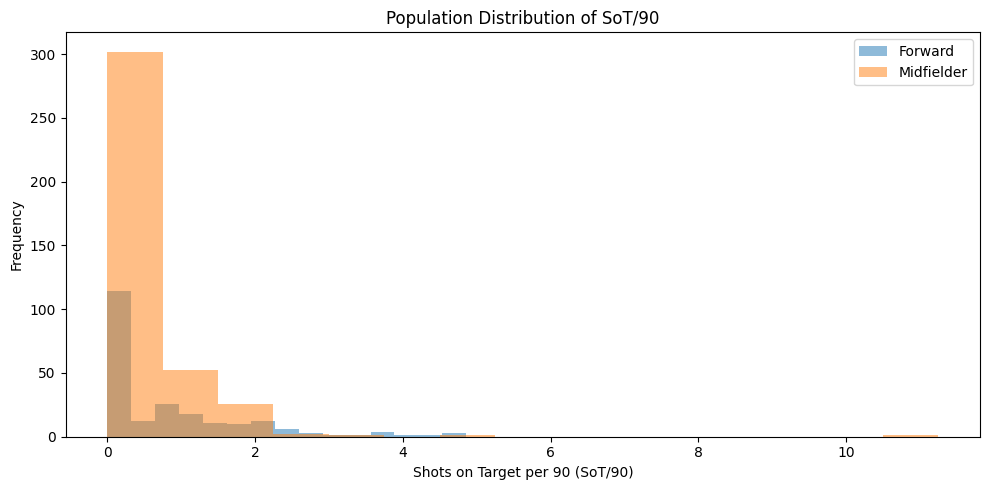

In [70]:
# Population histograms before sampling.
plt.figure(figsize=(10, 5)) #Set the figure size

# Loop through each position group and create a histogram of SoT/90 for players in that group, with different colors and labels for each position.
for position in ["Forward", "Midfielder"]:
    subset = df_prepared[df_prepared["Position_Group"] == position]["SoT/90"]
    plt.hist(subset, bins=15, alpha=0.5, label=position)#set the number of bins to 15, set the transparency to 0.5, and label each histogram with the corresponding position group.

# Add titles, labels, legend, and layout adjustments to the histogram.
plt.title("Population Distribution of SoT/90")
plt.xlabel("Shots on Target per 90 (SoT/90)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


In [71]:
# Reproducible stratified random sampling.
# We sample the same number from each position because the research question directly compares the two groups.
SAMPLE_SIZE_PER_GROUP = 64
RANDOM_STATE = 42 #set a random seed for reproducibility of the random sampling process, ensuring that the same sample can be obtained in future runs of the code.

#select the forwards and midfielders from the prepared DataFrame based on their position group.
forwards = df_prepared[df_prepared["Position_Group"] == "Forward"]
midfielders = df_prepared[df_prepared["Position_Group"] == "Midfielder"]

#loop through each position group and check if
if len(forwards) < SAMPLE_SIZE_PER_GROUP or len(midfielders) < SAMPLE_SIZE_PER_GROUP:
    raise ValueError("One position group contains fewer than 64 eligible players.")

#create a new DataFrame by randomly sampling 64 players from each position group, using the specified random seed for reproducibility.
forward_sample = forwards.sample(n=SAMPLE_SIZE_PER_GROUP, random_state=RANDOM_STATE)
midfielder_sample = midfielders.sample(n=SAMPLE_SIZE_PER_GROUP, random_state=RANDOM_STATE)

#Join the two samples into a single DataFrame, resetting the index to ensure a clean sequential index.
sample_df = pd.concat([forward_sample, midfielder_sample], ignore_index=True)

#print the sample size by position group and the total sample size, as well as the number of potential IQR outliers that happened to enter the random sample, grouped by position.
print("Sample size by position:")
print(sample_df["Position_Group"].value_counts())
print("\nTotal sample size:", len(sample_df))

# Check how many potential IQR outliers happened to enter the random sample.
print("\nPotential outliers in the selected sample:")
print(sample_df.groupby("Position_Group")["Potential_Outlier"].sum())


Sample size by position:
Position_Group
Forward       64
Midfielder    64
Name: count, dtype: int64

Total sample size: 128

Potential outliers in the selected sample:
Position_Group
Forward       2
Midfielder    6
Name: Potential_Outlier, dtype: int64


A balanced stratified random sampling method was used to select 64 Forwards and 64 Midfielders. Equal sample sizes were chosen to provide a consistent basis for comparing the two positional groups and to ensure adequate representation of each group. A fixed random state of 42 was used to make the sampling reproducible.The sample size chosen "64" is within the recommended sample size to be used as mentioned in class.

In [72]:
# Export sampled layer file to be used in subsequent notebooks.

sample_df.to_csv("sampled_Player_data.csv",
                 index=False, encoding="utf-8-sig")

print("Exported layer :")

print("sampled_Player_data.csv")



Exported layer :
sampled_Player_data.csv
